# Maybe a more efficient way of getting Colloidal vs Particulate profiles in the WC

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from matplotlib.path import Path
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path


In [11]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [12]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [13]:
stations = ['JF2', 'HS', 'S4-1.5', 'S2', 'NG', 'S1 (plume)', 'S3', 'FR']
lat = np.array([48 + (18/60), 48 + (37.80/60) , 49 + (15/60) , 49 + (17.58/60) , 49 + (43.60/60), 49 + (12.32/60), 49 + (17.88/60), 49 + (08.66/60)])
lon = (-1) * np.array([124, 123 + (14.60/60), 123 + (40/60), 123 + (22.51/60), 124 + (40.80/60), 123 + (18/60), 123 + (04.91/60), 123 + (02.65/60)]) 
#
x_obs = np.zeros_like(lon, dtype=int)
y_obs = np.zeros_like(lat, dtype=int)
for j in range(len(lon)):
    jj, ii = finder(lat[j], lon[j])
    x_obs[j] = ii
    y_obs[j] = jj

In [14]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

divide data per perticles depth ranges (0-10), (10-20), etc... Then ger the particles inside polygon and apply the rest... Automate so it's actually faster and more efficient

In [15]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_2.nc'

In [16]:
d1 = xr.open_dataset(filename1)
d2 = xr.open_dataset(filename2)

# Time binned per depth

In [17]:
def get_binned_timeseries(filename, polygon_coords, 
                          z_var='z', lon_var='lon', lat_var='lat', status_var='status', 
                          target_status=None, step=10):
    
    poly_path = Path(polygon_coords)
    timeseries_dict = {}
    
    with xr.open_dataset(filename) as data:
        z_vals = data[z_var].values
        lon_vals = data[lon_var].values
        lat_vals = data[lat_var].values
        
        # Get the number of time steps (obs dimension)
        # OceanParcels shape is usually (trajectory, obs)
        n_obs = z_vals.shape[1] 
        
        # --- UPFRONT STATUS FILTERING ---
        if target_status is not None:
            status_vals = data[status_var].values
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_vals, target_status)
            else:
                status_mask = status_vals == target_status
        else:
            status_mask = np.ones_like(z_vals, dtype=bool)
        # --------------------------------------
        
        if not np.any(status_mask):
            return pd.DataFrame()
            
        min_depth = np.nanmin(z_vals[status_mask])
        max_depth = np.nanmax(z_vals[status_mask])
        current_z = np.floor(min_depth / step) * step
        
        while current_z < max_depth:
            next_z = current_z + step
            bin_label = f"{int(current_z)}-{int(next_z)}"
            
            # 1. Create a mask for just this depth bin AND the correct status
            depth_mask = (z_vals >= current_z) & (z_vals < next_z)
            valid_mask = status_mask & depth_mask
            
            # Array to hold the counts for each time step
            counts_per_time = np.zeros(n_obs, dtype=int)
            
            if np.any(valid_mask):
                # 2. Extract valid coords and check if inside polygon
                valid_lon = lon_vals[valid_mask]
                valid_lat = lat_vals[valid_mask]
                points = np.column_stack((valid_lon, valid_lat))
                inside_poly = poly_path.contains_points(points)
                
                if np.any(inside_poly):
                    # 3. Get the 'obs' (time) indices of the points that matched
                    # np.where(valid_mask)[1] extracts the column (obs) index
                    valid_obs_idx = np.where(valid_mask)[1]
                    inside_obs_idx = valid_obs_idx[inside_poly]
                    
                    # 4. Tally the occurrences per time step instantly
                    counts_per_time = np.bincount(inside_obs_idx, minlength=n_obs)
            
            timeseries_dict[bin_label] = counts_per_time
            current_z = next_z
            
    # Return as a DataFrame (Rows = time steps, Columns = depth bins)
    return pd.DataFrame(timeseries_dict)

# SSOG

In [18]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

# Colloidal (Status 2)

In [19]:
df_y1_C = get_binned_timeseries(filename1, polygon_lon_lat_S1, target_status=2)
df_y2_C = get_binned_timeseries(filename2, polygon_lon_lat_S1, target_status=2)
df_y2_total_C = df_y1_C.add(df_y2_C, fill_value=0)
full_2yr_timeseries_C = pd.concat([df_y1_C, df_y2_total_C], ignore_index=True)

In [20]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_C.mean(),
    'Std_Dev': full_2yr_timeseries_C.std()
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

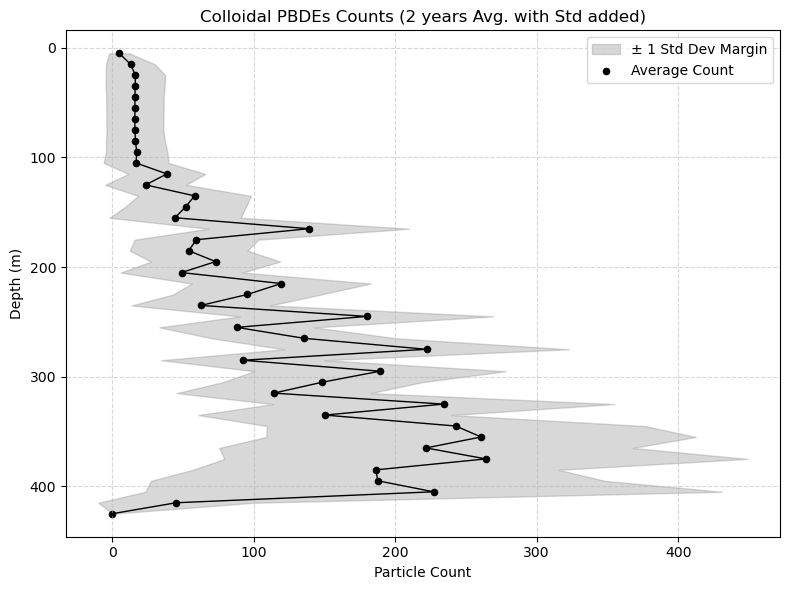

In [21]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in final_stats_C.index])

# Extract values
mean_count = final_stats_C['Mean_Count'].values
std_dev = final_stats_C['Std_Dev'].values

plt.figure(figsize=(8, 6))

# 2. Plot the shaded +/- std margin
plt.fill_betweenx(
    y_midpoints, 
    mean_count - std_dev, 
    mean_count + std_dev, 
    color='gray', 
    alpha=0.3, 
    label='± 1 Std Dev Margin'
)

# 3. Plot the basic average line with dots at the exact bin midpoints
# 'k-o' creates a black line with circular markers
plt.scatter(mean_count, y_midpoints, marker = 'o', s = 20, c = 'k', label='Average Count')
plt.plot(mean_count, y_midpoints,'k', linewidth = 1)


# 4. Format the plot
plt.gca().invert_yaxis()  # Depth goes down
plt.xlabel('Particle Count')
plt.ylabel('Depth (m)')
plt.title('Colloidal PBDEs Counts (2 years Avg. with Std added)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Particulate (Status 1 and 3)

In [22]:
df_y1_P = get_binned_timeseries(filename1, polygon_lon_lat_S1, target_status=[1,3])
df_y2_P = get_binned_timeseries(filename2, polygon_lon_lat_S1, target_status=[1,3])
df_y2_total_P = df_y1_P.add(df_y2_P, fill_value=0)
full_2yr_timeseries_P = pd.concat([df_y1_P, df_y2_total_P], ignore_index=True)

In [23]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_P.mean(),
    'Std_Dev': full_2yr_timeseries_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

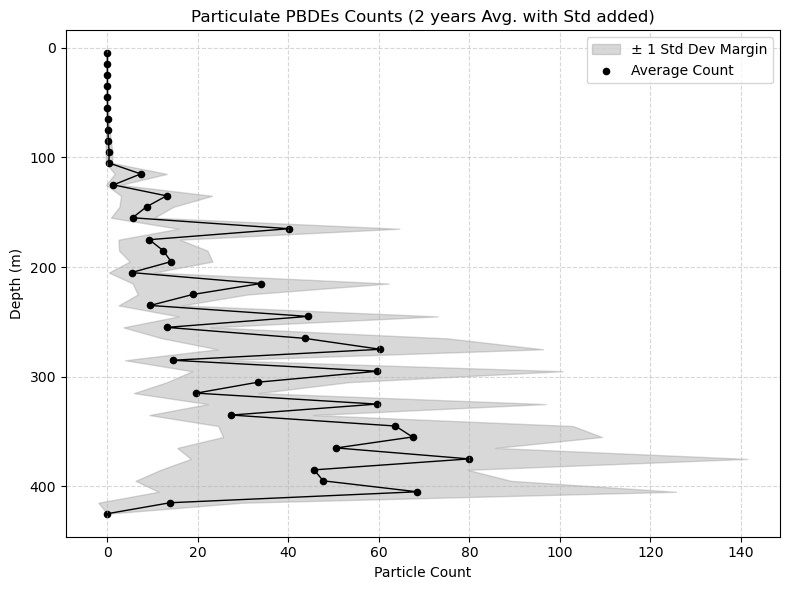

In [24]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in final_stats_P.index])

# Extract values
mean_count = final_stats_P['Mean_Count'].values
std_dev = final_stats_P['Std_Dev'].values

plt.figure(figsize=(8, 6))

# 2. Plot the shaded +/- std margin
plt.fill_betweenx(
    y_midpoints, 
    mean_count - std_dev, 
    mean_count + std_dev, 
    color='gray', 
    alpha=0.3, 
    label='± 1 Std Dev Margin'
)

# 3. Plot the basic average line with dots at the exact bin midpoints
# 'k-o' creates a black line with circular markers
plt.scatter(mean_count, y_midpoints, marker = 'o', s = 20, c = 'k', label='Average Count')
plt.plot(mean_count, y_midpoints,'k', linewidth = 1)


# 4. Format the plot
plt.gca().invert_yaxis()  # Depth goes down
plt.xlabel('Particle Count')
plt.ylabel('Depth (m)')
plt.title('Particulate PBDEs Counts (2 years Avg. with Std added)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
depth_avg_S4_15_0 = [25, 25, 25, 25, 25, 25, 25, 25, 25, 25]
part_S4_15_0 = [0.2, 1.6, 0.2, 0.7, 0.9, 1.1, 2.5, 2.6, 0.4, 1.0]
#
depth_avg_S4_15_1 = [150, 150, 150, 150, 150, 150, 150, 150, 150, 150]
part_S4_15_1 = [0.2, 1.2, 2.0, 6.6, 1.1, 1.4, 0.1, 1.2, 0.4, 1.0]
#
depth_deep = depth_avg_S4_15_1[0]
depth_shallow = depth_avg_S4_15_0[0]
part_S4_15_0_comp = [100 - v for v in part_S4_15_0]
part_S4_15_1_comp = [100 - v for v in part_S4_15_1]

In [26]:
ts_total = full_2yr_timeseries_C + full_2yr_timeseries_P

In [27]:
ts_pct_C = (full_2yr_timeseries_C / ts_total) * 100
ts_pct_P = (full_2yr_timeseries_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

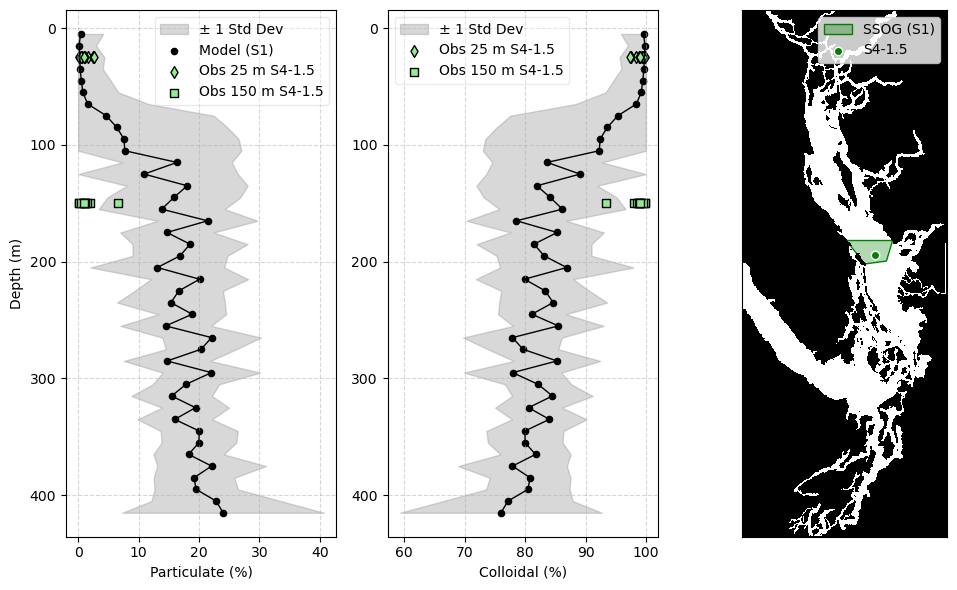

In [28]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

# 2. Extract the true calculated values and clip them between 0 and 100 for the shading
mean_C = true_stats_C['Mean_Pct']
std_C = true_stats_C['Std_Pct']
lower_C = np.clip(mean_C - std_C, 0, 100)
upper_C = np.clip(mean_C + std_C, 0, 100)

mean_P = true_stats_P['Mean_Pct']
std_P = true_stats_P['Std_Pct']
lower_P = np.clip(mean_P - std_P, 0, 100)
upper_P = np.clip(mean_P + std_P, 0, 100)

# 3. Create the figure with 2 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

#
ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k', label = 'Model (S1)')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)
#
#
# OBS
ax1.scatter(part_S4_15_0, depth_avg_S4_15_0, c = 'lightgreen', marker = 'd', edgecolor = 'k', label=f'Obs {depth_shallow} m S4-1.5')
ax1.scatter(part_S4_15_1, depth_avg_S4_15_1, c = 'lightgreen', marker = 's', edgecolor = 'k', label=f'Obs {depth_deep} m S4-1.5')
#
ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
#ax1.set_title('Particulate PBDEs')
ax1.grid(True, linestyle='--', alpha=0.5)

#
ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)
#
#
# OBS
ax2.scatter(part_S4_15_0_comp, depth_avg_S4_15_0, c = 'lightgreen', marker = 'd', edgecolor = 'k', label=f'Obs {depth_shallow} m S4-1.5')
ax2.scatter(part_S4_15_1_comp, depth_avg_S4_15_1, c = 'lightgreen', marker = 's', edgecolor = 'k', label=f'Obs {depth_deep} m S4-1.5')
#
ax2.set_xlabel('Colloidal (%)')
#ax2.set_title('Colloidal PBDEs')
ax2.grid(True, linestyle='--', alpha=0.5)
#

#ax1.set_xlim(0, 50)
#ax2.set_xlim(50, 100)
#
plot_polygon(polygon_S1, ax=ax3, color='g', label = 'SSOG (S1)',add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax3.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax3.scatter(x_obs[2], y_obs[2], marker = 'o', edgecolors='w', c = 'g', label = stations[2])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax3.set_aspect(f); ax3.legend(loc = 'upper right')
for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha = .4)
plt.tight_layout()
plt.show()

# NSOG

In [29]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1

In [30]:
depth_avg_NG_0 = [25, 25]
part_NG_0 = [5, 15]
#
depth_avg_NG_1 = [150, 150]
part_NG_1 = [11, 55]
#
depth_shallow = depth_avg_NG_0[1]
depth_deep = depth_avg_NG_1[0]

In [31]:
df_y1_C = get_binned_timeseries(filename1, polygon_lon_lat_N1, target_status=2)
df_y2_C = get_binned_timeseries(filename2, polygon_lon_lat_N1, target_status=2)
df_y2_total_C = df_y1_C.add(df_y2_C, fill_value=0)
full_2yr_timeseries_C = pd.concat([df_y1_C, df_y2_total_C], ignore_index=True)

In [32]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_C.mean(),
    'Std_Dev': full_2yr_timeseries_C.std()
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

In [33]:
df_y1_P = get_binned_timeseries(filename1, polygon_lon_lat_N1, target_status=[1,3])
df_y2_P = get_binned_timeseries(filename2, polygon_lon_lat_N1, target_status=[1,3])
df_y2_total_P = df_y1_P.add(df_y2_P, fill_value=0)
full_2yr_timeseries_P = pd.concat([df_y1_P, df_y2_total_P], ignore_index=True)

In [34]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_P.mean(),
    'Std_Dev': full_2yr_timeseries_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

In [35]:
ts_total = full_2yr_timeseries_C + full_2yr_timeseries_P

In [36]:
ts_pct_C = (full_2yr_timeseries_C / ts_total) * 100
ts_pct_P = (full_2yr_timeseries_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

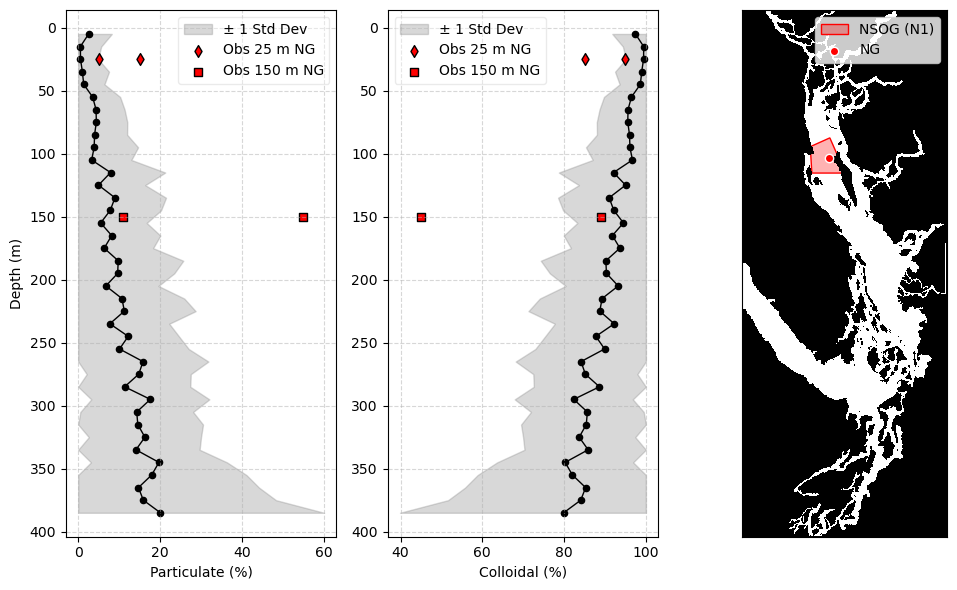

In [37]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

# 2. Extract the true calculated values and clip them between 0 and 100 for the shading
mean_C = true_stats_C['Mean_Pct']
std_C = true_stats_C['Std_Pct']
lower_C = np.clip(mean_C - std_C, 0, 100)
upper_C = np.clip(mean_C + std_C, 0, 100)

mean_P = true_stats_P['Mean_Pct']
std_P = true_stats_P['Std_Pct']
lower_P = np.clip(mean_P - std_P, 0, 100)
upper_P = np.clip(mean_P + std_P, 0, 100)

# 3. Create the figure with 2 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

#
ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)
#
#
# OBS
ax1.scatter(part_NG_0, depth_avg_NG_0, c='r', marker = 'd', edgecolor = 'k', label=f'Obs {depth_shallow} m NG')
ax1.scatter(part_NG_1, depth_avg_NG_1, c = 'r', marker = 's', edgecolor = 'k', label=f'Obs {depth_deep} m NG')
#
ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
#ax1.set_title('Particulate PBDEs')
ax1.grid(True, linestyle='--', alpha=0.5)

#
ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)
#
#
# OBS
part_NG_0_comp = [100 - v for v in part_NG_0]
part_NG_1_comp = [100 - v for v in part_NG_1]
ax2.scatter(part_NG_0_comp, depth_avg_NG_0, c = 'r', marker = 'd', edgecolor = 'k', label=f'Obs {depth_shallow} m NG')
ax2.scatter(part_NG_1_comp, depth_avg_NG_1, c = 'r', marker = 's', edgecolor = 'k', label=f'Obs {depth_deep} m NG')

#
ax2.set_xlabel('Colloidal (%)')
#ax2.set_title('Colloidal PBDEs')
ax2.grid(True, linestyle='--', alpha=0.5)
#

#ax1.set_xlim(0, 60)
#ax2.set_xlim(50, 100)
#
plot_polygon(polygon_N1, ax=ax3, color='r', label = 'NSOG (N1)', add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax3.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax3.scatter(x_obs[4], y_obs[4], marker = 'o', edgecolors='w', c = 'r', label = stations[4])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax3.set_aspect(f); ax3.legend(loc = 'upper right')
for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha = .4)    
plt.tight_layout()
plt.show()

# Iona Plume

In [38]:
from Regions_functions_V2 import polygon_SP, polygon_lon_lat_SP

In [39]:
depth_avg_S1 = [60, 60]
part_S1 = [17, 29]
#
depth_avg_S2_0 = [50, 50, 50, 50]
part_S2_0 = [14, 15, 0.1, 0.5]
#
depth_avg_S2_1 = [60, 60]
part_S2_1 = [0.4, 2.3]

In [40]:
depth_S1 = depth_avg_S1
part_S1 = part_S1
# S2 
depth_S2 = depth_avg_S2_0 + depth_avg_S2_1
part_S2 = part_S2_0 + part_S2_1

In [41]:
df_y1_C = get_binned_timeseries(filename1, polygon_lon_lat_SP, target_status=2)
df_y2_C = get_binned_timeseries(filename2, polygon_lon_lat_SP, target_status=2)
df_y2_total_C = df_y1_C.add(df_y2_C, fill_value=0)
full_2yr_timeseries_C = pd.concat([df_y1_C, df_y2_total_C], ignore_index=True)

In [42]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_C.mean(),
    'Std_Dev': full_2yr_timeseries_C.std()
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

In [43]:
df_y1_P = get_binned_timeseries(filename1, polygon_lon_lat_SP, target_status=[1,3])
df_y2_P = get_binned_timeseries(filename2, polygon_lon_lat_SP, target_status=[1,3])
df_y2_total_P = df_y1_P.add(df_y2_P, fill_value=0)
full_2yr_timeseries_P = pd.concat([df_y1_P, df_y2_total_P], ignore_index=True)

In [44]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_2yr_timeseries_P.mean(),
    'Std_Dev': full_2yr_timeseries_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

In [45]:
ts_total = full_2yr_timeseries_C + full_2yr_timeseries_P

In [46]:
ts_pct_C = (full_2yr_timeseries_C / ts_total) * 100
ts_pct_P = (full_2yr_timeseries_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

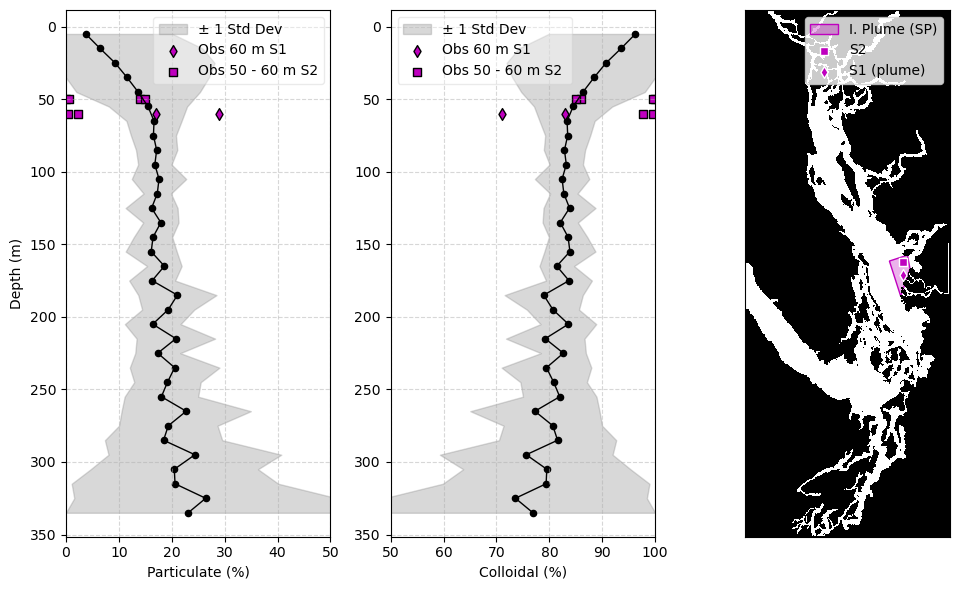

In [47]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

# 2. Extract the true calculated values and clip them between 0 and 100 for the shading
mean_C = true_stats_C['Mean_Pct']
std_C = true_stats_C['Std_Pct']
lower_C = np.clip(mean_C - std_C, 0, 100)
upper_C = np.clip(mean_C + std_C, 0, 100)

mean_P = true_stats_P['Mean_Pct']
std_P = true_stats_P['Std_Pct']
lower_P = np.clip(mean_P - std_P, 0, 100)
upper_P = np.clip(mean_P + std_P, 0, 100)

# 3. Create the figure with 2 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

#
ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)
#
#
# OBS
ax1.scatter(part_S1, depth_S1, c='m', marker='d', edgecolor = 'k', label=f'Obs {depth_S1[0]} m S1')
ax1.scatter(part_S2, depth_S2, c='m', marker='s', edgecolor = 'k', label=f'Obs {depth_S2[0]} - {depth_S2[-1]} m S2')

#
ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
#ax1.set_title('Particulate PBDEs')
ax1.grid(True, linestyle='--', alpha=0.5)

#
ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)
#
#
# OBS
part_S1_comp = [100 - p for p in part_S1]
part_S2_comp = [100 - p for p in part_S2]
ax2.scatter(part_S1_comp, depth_S1, c='m', marker='d',edgecolor = 'k',  label=f'Obs {depth_S1[0]} m S1 ')
ax2.scatter(part_S2_comp, depth_S2, c='m', marker='s', edgecolor = 'k', label=f'Obs {depth_S2[0]} - {depth_S2[-1]} m S2 ')
#
ax2.set_xlabel('Colloidal (%)')
#ax2.set_title('Colloidal PBDEs')
ax2.grid(True, linestyle='--', alpha=0.5)
#

ax1.set_xlim(0, 50)
ax2.set_xlim(50, 100)
#
plot_polygon(polygon_SP, ax=ax3, color='m', label = 'I. Plume (SP)', add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c = colors_regions[6],s = 20,  marker = 's')
#ax3.scatter(points_x_N3, points_y_N3, c = colors_regions[6],s = 20,  marker = 's')

ax3.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax3.scatter(x_obs[3], y_obs[3], marker = 's', edgecolors='w', c = 'm', label = stations[3])
ax3.scatter(x_obs[5], y_obs[5], marker = 'd', edgecolors='w', c = 'm' , label = stations[5])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
f = 1.14
ax3.set_aspect(f); ax3.legend(loc = 'upper right')
for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha = .4)    
plt.tight_layout()
plt.show()